In [1]:
import pandas as pd


TH = pd.read_csv(
    "classification/TomsHardware/Absolute_labeling/TomsHardware-Absolute-Sigma-500.data",
    sep=",",
    header=None
)
TH_1000 = pd.read_csv(
    "classification/TomsHardware/Relative_labeling/sigma=1000/TomsHardware-Relative-Sigma-1000.data",
    sep=",",
    header=None
)
TH_1500 = pd.read_csv(
    "classification/TomsHardware/Relative_labeling/sigma=1500/TomsHardware-Relative-Sigma-1500.data",
    sep=",",
    header=None
)

TH_reg = pd.read_csv(
    "regression/TomsHardware/TomsHardware.data",
    sep=",",
    header=None
)

In [2]:

groups = [
    "NCD", "BL", "NAD", "AI", "NAC", "ND",
    "CS", "AT", "NA", "ADL", "AS_NA", "AS_NAC"
]

columns = []
for group in groups:
    for t in range(8):
        columns.append(f"{group}_{t}")

columns.append("label")  # остання колонка

TH.columns = columns
TH_1000.columns=columns
TH_1500.columns=columns
TH_reg.columns = columns

In [3]:
prefixes = {col.split("_")[0] for col in TH.columns if "_" in col}
prefixes

{'ADL', 'AI', 'AS', 'AT', 'BL', 'CS', 'NA', 'NAC', 'NAD', 'NCD', 'ND'}

In [4]:
def feature_stats(df, prefix):
    return df[[c for c in df.columns if c.startswith(prefix + "_")]] \
        .describe().T[["min", "max", "mean", "std"]]

feature_stats(TH, "ADL")

,min,max,mean,std
ADL_0,0.0,150.0,12.377154,23.653515
ADL_1,0.0,150.0,11.905098,22.637965
ADL_2,0.0,150.0,11.994069,22.480400
ADL_3,0.0,150.0,13.226835,24.111336
ADL_4,0.0,150.0,12.753941,23.192514
ADL_5,0.0,150.0,12.954777,23.730964
ADL_6,0.0,150.0,13.619735,23.764482
ADL_7,0.0,150.0,14.916081,25.322417


In [5]:
TW = pd.read_csv(
    "classification/Twitter/Absolute_labeling/Twitter-Absolute-Sigma-500.data",
    sep=",",
    header=None
)
TW_1000 = pd.read_csv(
    "classification/Twitter/Relative_labeling/sigma=1000/Twitter-Relative-Sigma-1000.data",
    sep=",",
    header=None
)
TW_1500 = pd.read_csv(
    "classification/Twitter/Relative_labeling/sigma=1500/Twitter-Relative-Sigma-1500.data",
    sep=",",
    header=None
)
TW_reg = pd.read_csv(
    "regression/Twitter/Twitter.data",
    sep=",",
    header=None
)

In [6]:

groups = ["NCD", 'AI', 'AS(NA)', 'BL',
         'NAC', 'AS(NAC)', 'CS', 'AT', 'NA','ADL', 'NAD']

columns = []
for group in groups:
    for t in range(7):
        columns.append(f"{group}_{t}")

columns.append("label")  # остання колонка

TW.columns = columns
TW_1000.columns = columns
TW_1500.columns = columns
TW_reg.columns = columns

In [7]:
TW.head(2)

,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,AI_0,AI_1,AI_2,...,ADL_5,ADL_6,NAD_0,NAD_1,NAD_2,NAD_3,NAD_4,NAD_5,NAD_6,label
0,889,939,960,805,805,1143,1121,549,613,587,...,1.0,1.0,889,939,960,805,805,1143,1121,1.0
1,542,473,504,626,647,795,832,366,288,318,...,1.0,1.0,542,473,504,626,647,795,832,1.0


In [8]:
def feature_TW(df, prefix):
    return df[[c for c in df.columns if c.startswith(prefix + "_")]] \
        .describe().T[["min", "max", "mean", "std"]]

feature_TW(TH, "NCD")

,min,max,mean,std
NCD_0,0.0,182.0,1.398988,6.213513
NCD_1,0.0,109.0,1.301075,5.596248
NCD_2,0.0,116.0,1.290323,5.440313
NCD_3,0.0,98.0,1.331942,5.508240
NCD_4,0.0,108.0,1.341176,5.364720
NCD_5,0.0,118.0,1.362176,5.347562
NCD_6,0.0,154.0,1.453637,5.642222
NCD_7,0.0,88.0,1.327261,4.974433


In [9]:
def dataset_overview(df, name):
    return {
        "dataset": name,
        "instances": df.shape[0],
        "features": df.shape[1] - 1,
        "nula_exist": df.isna().sum().sum(),
        "buzz_1": int((df["label"] == 1).sum()),
        "buzz_0": int((df["label"] == 0).sum()),
        "buzz_ratio": round((df["label"] == 1).mean(), 3)
    }

pd.DataFrame([
    dataset_overview(TH, "TomsHardware_500"),
    dataset_overview(TW, "Twitter_500")
])


,dataset,instances,features,nula_exist,buzz_1,buzz_0,buzz_ratio
0,TomsHardware_500,7905,96,0,4860,3045,0.615
1,Twitter_500,140707,77,0,27775,112932,0.197


In [10]:
pd.DataFrame([
    dataset_overview(TH_1000, "TomsHardware_1000"),
    dataset_overview(TW_1000, "Twitter_1000")
])


,dataset,instances,features,nula_exist,buzz_1,buzz_0,buzz_ratio
0,TomsHardware_1000,7905,96,0,1110,6795,0.140
1,Twitter_1000,140707,77,0,1177,139530,0.008


In [11]:
pd.DataFrame([
    dataset_overview(TH_1500, "TomsHardware_1500"),
    dataset_overview(TW_1500, "Twitter_1500")
])

,dataset,instances,features,nula_exist,buzz_1,buzz_0,buzz_ratio
0,TomsHardware_1500,7905,96,0,841,7064,0.106
1,Twitter_1500,140707,77,0,488,140219,0.003


In [12]:
pd.DataFrame([
    dataset_overview(TH_reg, "TomsHardware_reg"),
    dataset_overview(TW_reg, "Twitter_reg")
])

,dataset,instances,features,nula_exist,buzz_1,buzz_0,buzz_ratio
0,TomsHardware_reg,28179,96,0,157,125,0.006
1,Twitter_reg,583250,77,0,19299,19094,0.033


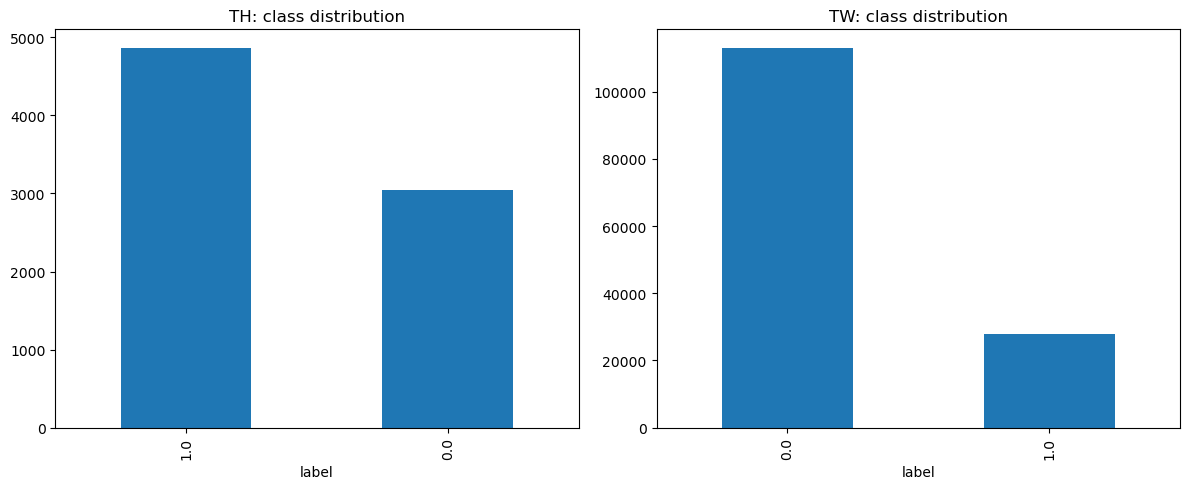

In [13]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

TH["label"].value_counts().plot(
    kind="bar",
    ax=axs[0],
    title="TH: class distribution"
)

TW["label"].value_counts().plot(
    kind="bar",
    ax=axs[1],
    title="TW: class distribution"
)

plt.tight_layout()
plt.show()


Ukladá sa do: /home/jovyan/work/Bakalarka


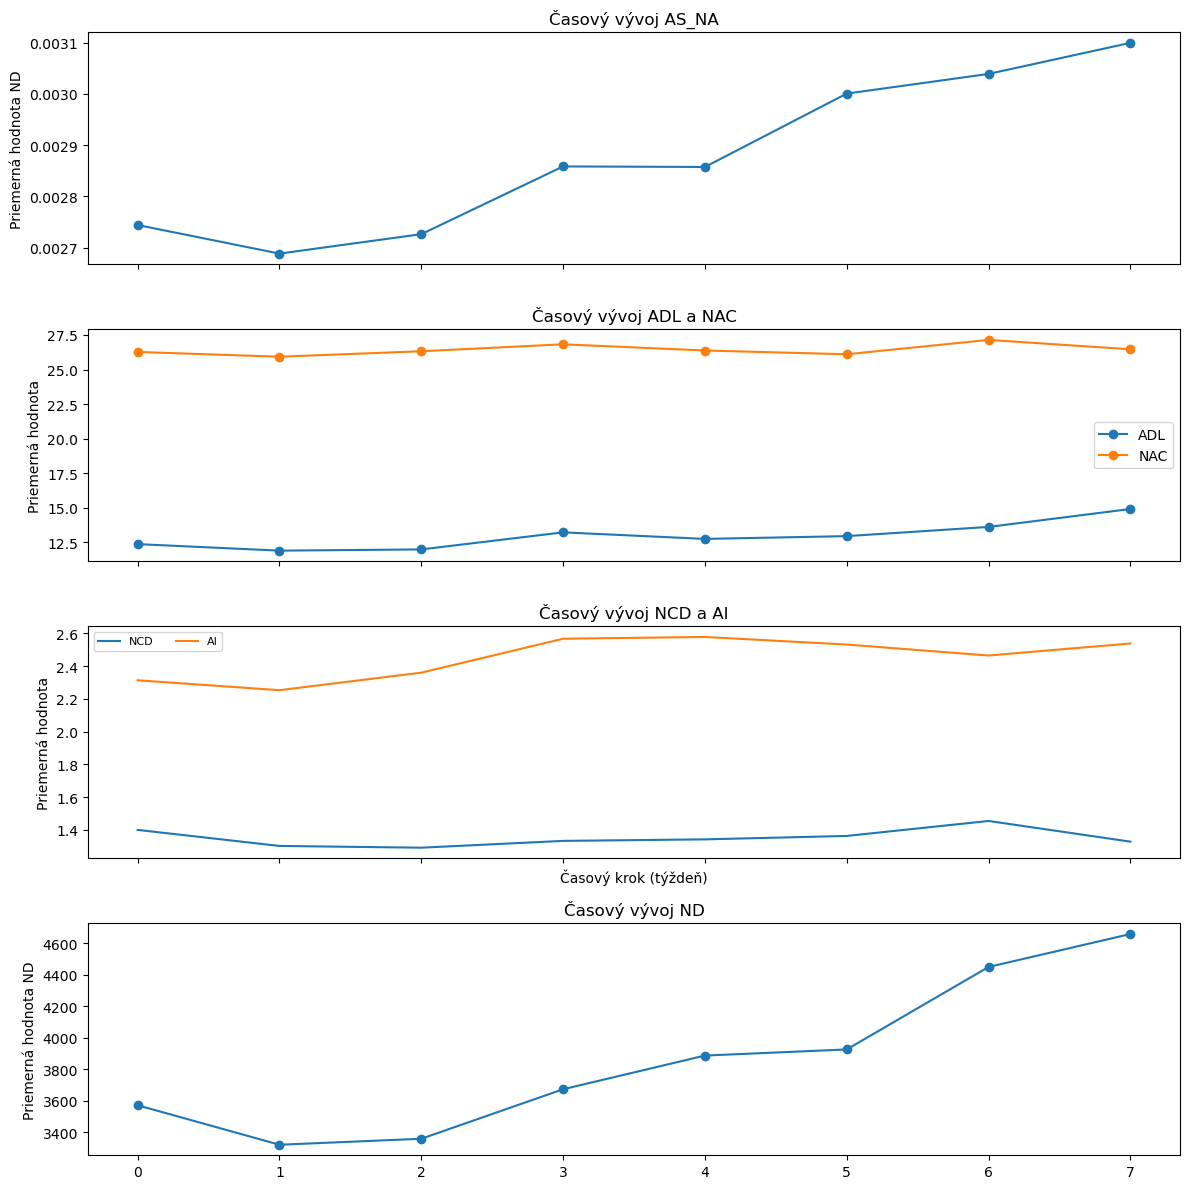

In [14]:
import matplotlib.pyplot as plt

time = range(8)

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# Subplot 1
nd_mean = [TH[f"AS_NA_{t}"].mean() for t in time] 
axes[0].plot(time, nd_mean, marker="o")
axes[0].set_title("Časový vývoj AS_NA")
axes[0].set_ylabel("Priemerná hodnota ND")


# Subplot 2
for f in ["ADL", "NAC"]:
    means = [TH[f"{f}_{t}"].mean() for t in time]
    axes[1].plot(time, means, marker="o", label=f)

axes[1].set_title("Časový vývoj ADL a NAC")
axes[1].set_ylabel("Priemerná hodnota")
axes[1].legend()

# Subplot 3
features = ["NCD", "AI"]

for f in features:
    means = [TH[f"{f}_{t}"].mean() for t in time]
    axes[2].plot(time, means, label=f)

axes[2].set_title("Časový vývoj NCD a AI")
axes[2].set_xlabel("Časový krok (týždeň)")
axes[2].set_ylabel("Priemerná hodnota")
axes[2].legend(ncol=3, fontsize=8)

# Subplot 4
nd_mean = [TH[f"ND_{t}"].mean() for t in time] 
axes[3].plot(time, nd_mean, marker="o")
axes[3].set_title("Časový vývoj ND")
axes[3].set_ylabel("Priemerná hodnota ND")


plt.tight_layout()
fig.savefig("grafy.png", dpi=300, bbox_inches="tight")
import os
print("Ukladá sa do:", os.getcwd())
plt.show()

Ukladá sa do: /home/jovyan/work/Bakalarka


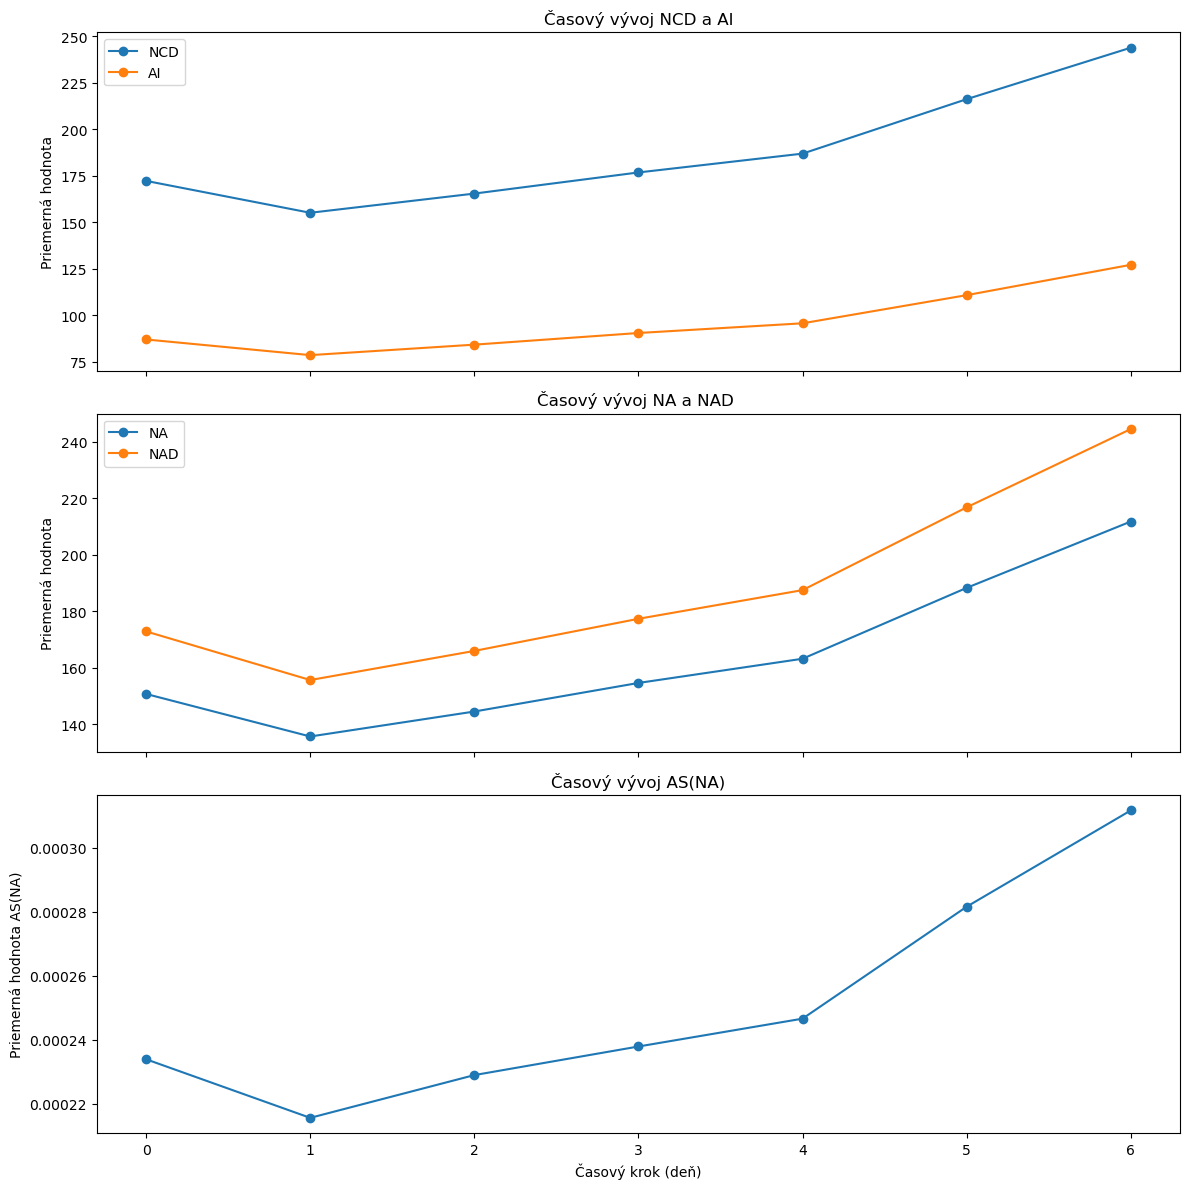

In [15]:
import matplotlib.pyplot as plt

time = range(7)

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# --- Subplot 1: NCD a AI ---
for f in ["NCD", "AI"]:
    means = [TW[f"{f}_{t}"].mean() for t in time]
    axes[0].plot(time, means, marker="o", label=f)

axes[0].set_title("Časový vývoj NCD a AI")
axes[0].set_ylabel("Priemerná hodnota")
axes[0].legend()

# --- Subplot 2: NA a NAD ---
for f in ["NA", "NAD"]:
    means = [TW[f"{f}_{t}"].mean() for t in time]
    axes[1].plot(time, means, marker="o", label=f)

axes[1].set_title("Časový vývoj NA a NAD ")
axes[1].set_ylabel("Priemerná hodnota")
axes[1].legend()

# --- Subplot 3: AS(NA) ---
asna_mean = [TW[f"AS(NA)_{t}"].mean() for t in time]
axes[2].plot(time, asna_mean, marker="o")
axes[2].set_title("Časový vývoj AS(NA)")
axes[2].set_xlabel("Časový krok (deň)")
axes[2].set_ylabel("Priemerná hodnota AS(NA)")

plt.tight_layout()
fig.savefig("grafy.png", dpi=300, bbox_inches="tight")

import os
print("Ukladá sa do:", os.getcwd())

plt.show()

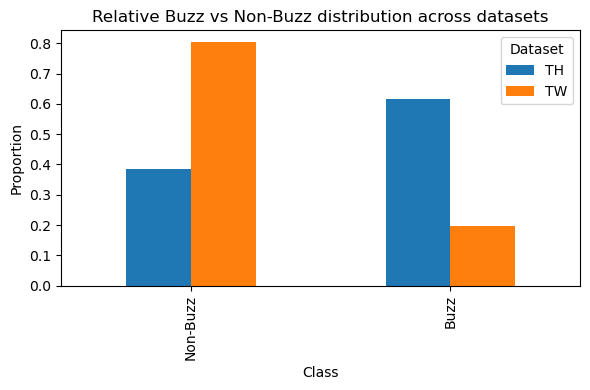

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

counts = pd.DataFrame({
    "TH": TH["label"].value_counts(normalize=True),
    "TW": TW["label"].value_counts(normalize=True)
})

counts = counts.sort_index()
counts.index = ["Non-Buzz", "Buzz"]

fig, ax = plt.subplots(figsize=(6, 4))

counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Relative Buzz vs Non-Buzz distribution across datasets")
ax.set_xlabel("Class")
ax.set_ylabel("Proportion")
ax.legend(title="Dataset")

plt.tight_layout()
plt.show()


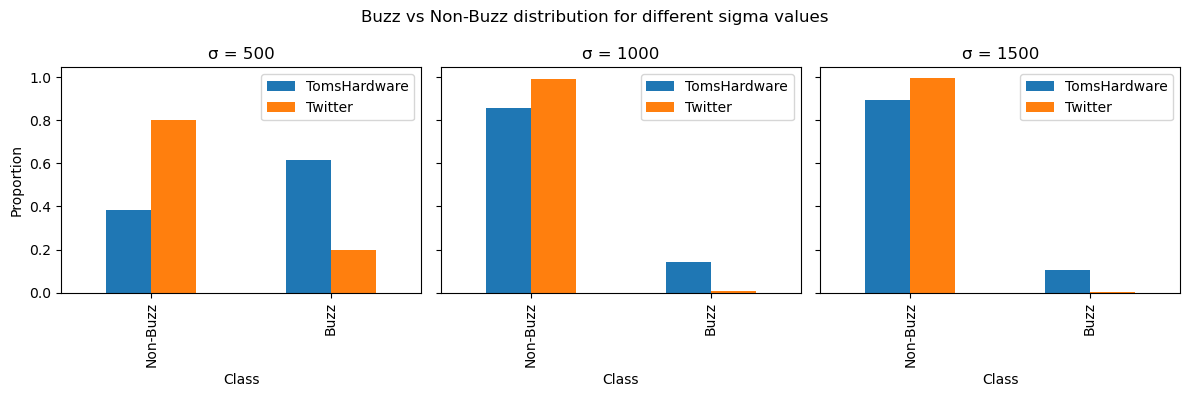

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# словник датасетів
datasets = {
    "σ = 500": (TH, TW),
    "σ = 1000": (TH_1000, TW_1000),
    "σ = 1500": (TH_1500, TW_1500)
}

fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, (sigma, (th, tw)) in zip(axs, datasets.items()):
    counts = pd.DataFrame({
        "TomsHardware": th.iloc[:, -1].value_counts(normalize=True),
        "Twitter": tw.iloc[:, -1].value_counts(normalize=True)
    }).sort_index()

    counts.index = ["Non-Buzz", "Buzz"]

    counts.plot(kind="bar", ax=ax)
    ax.set_title(sigma)
    ax.set_xlabel("Class")
    ax.set_ylabel("Proportion")

plt.suptitle("Buzz vs Non-Buzz distribution for different sigma values")
plt.tight_layout()
plt.show()


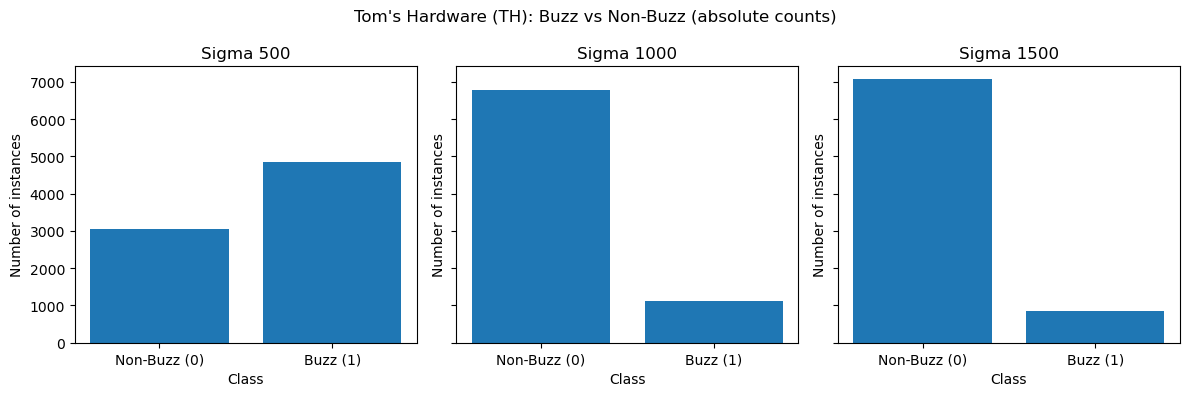

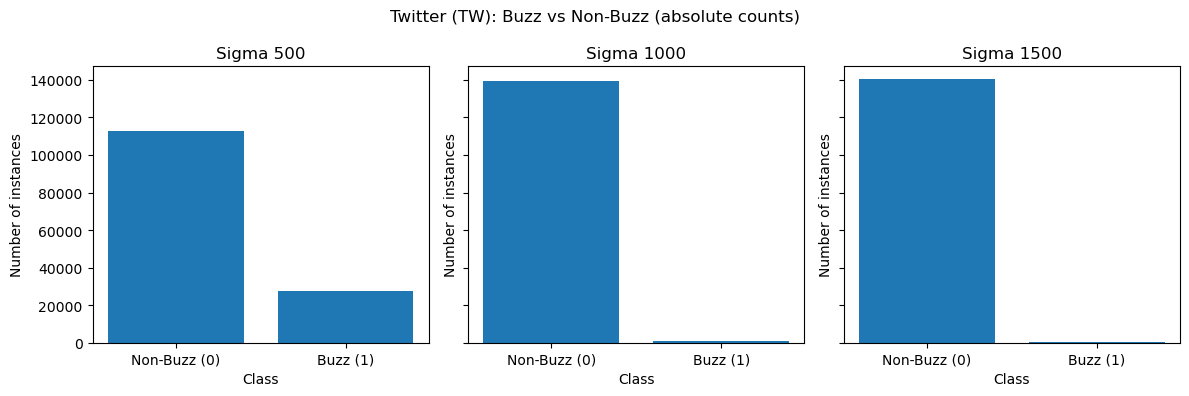

In [20]:
import matplotlib.pyplot as plt

def plot_counts_by_sigma(df_500, df_1000, df_1500, title_prefix):
    sigmas = [("Sigma 500", df_500), ("Sigma 1000", df_1000), ("Sigma 1500", df_1500)]

    fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

    for ax, (sigma_name, df) in zip(axs, sigmas):
        counts = df.iloc[:, -1].value_counts().sort_index()

        ax.bar(["Non-Buzz (0)", "Buzz (1)"], [counts.get(0, 0), counts.get(1, 0)])
        ax.set_title(sigma_name)
        ax.set_xlabel("Class")
        ax.set_ylabel("Number of instances")

    fig.suptitle(f"{title_prefix}: Buzz vs Non-Buzz (absolute counts)")
    plt.tight_layout()
    plt.show()


# 1) TH: 3 sigma
plot_counts_by_sigma(TH, TH_1000, TH_1500, "Tom's Hardware (TH)")

# 2) TW: 3 sigma
plot_counts_by_sigma(TW, TW_1000, TW_1500, "Twitter (TW)")


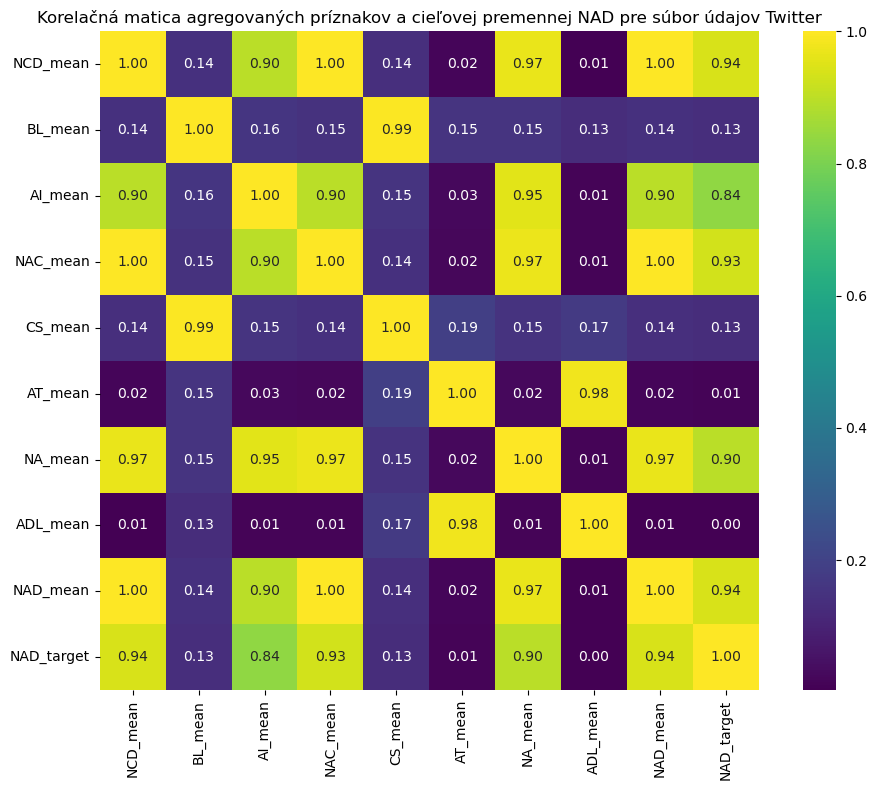

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- target (майбутній NAD) ----
NAD_target = TW_reg.iloc[:, -1]

# ---- агрегуємо історичні ознаки (t = 0..6) ----
base_features = [
    "NCD", "BL", "AI", "NAC",
    "CS", "AT", "NA", "ADL", "NAD"
]

agg_features = {}

for feature in base_features:
    cols = [c for c in TW_reg.columns if c.startswith(feature + "_")]
    agg_features[f"{feature}_mean"] = TW_reg[cols].mean(axis=1)

agg_df = pd.DataFrame(agg_features)

# ---- додаємо target для кореляції ----
agg_df["NAD_target"] = NAD_target

# ---- кореляційна матриця ----
corr = agg_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    square=True
)
plt.title("Korelačná matica agregovaných príznakov a cieľovej premennej NAD pre súbor údajov Twitter")
plt.tight_layout()
plt.show()


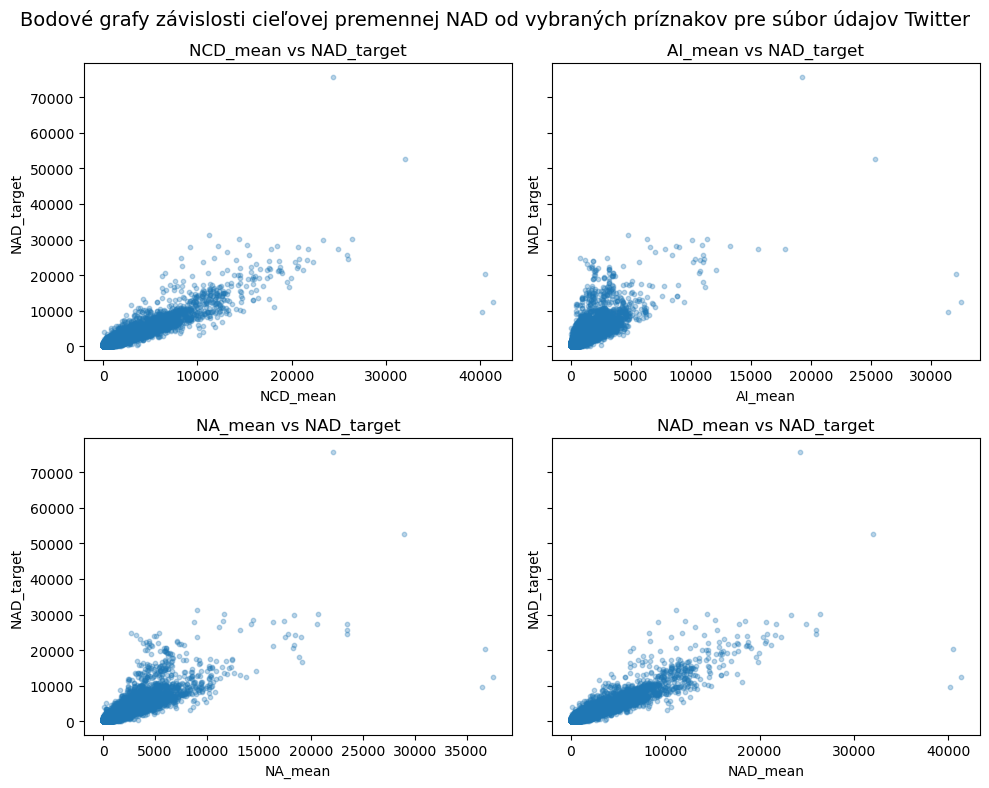

In [23]:
import matplotlib.pyplot as plt

features = ["NCD_mean", "AI_mean", "NA_mean", "NAD_mean"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
axes = axes.flatten()

for ax, feature in zip(axes, features):
    ax.scatter(
        agg_df[feature],
        agg_df["NAD_target"],
        alpha=0.3,
        s=10
    )
    ax.set_xlabel(feature)
    ax.set_ylabel("NAD_target")
    ax.set_title(f"{feature} vs NAD_target")

plt.suptitle("Bodové grafy závislosti cieľovej premennej NAD od vybraných príznakov pre súbor údajov Twitter", fontsize=14)
plt.tight_layout()
plt.show()


In [31]:
TW.head(20)

,NCD_0,NCD_1,NCD_2,NCD_3,NCD_4,NCD_5,NCD_6,AI_0,AI_1,AI_2,...,ADL_5,ADL_6,NAD_0,NAD_1,NAD_2,NAD_3,NAD_4,NAD_5,NAD_6,label
0,889,939,960,805,805,1143,1121,549,613,587,...,1.000000,1.000000,889,939,960,805,805,1143,1121,1.0
1,542,473,504,626,647,795,832,366,288,318,...,1.000000,1.000000,542,473,504,626,647,795,832,1.0
2,92,99,196,100,184,79,162,66,59,118,...,1.000000,1.000000,92,99,196,100,184,79,162,0.0
3,90,87,92,344,184,848,184,83,78,76,...,1.000000,1.000000,90,87,92,344,184,848,184,1.0
4,169,98,101,90,96,95,185,141,68,85,...,1.000000,1.000000,169,98,101,90,96,95,185,1.0
5,775,765,935,806,912,1095,1198,614,588,751,...,1.000000,1.000000,775,765,935,806,912,1095,1198,1.0
6,469,1092,332,354,357,676,1189,348,909,261,...,1.000000,1.000000,469,1092,332,354,357,676,1189,1.0
7,818,693,756,1099,877,871,1409,578,516,546,...,1.000000,1.000000,818,693,756,1099,877,871,1409,1.0
8,832,628,898,944,993,983,1037,543,432,627,...,1.000000,1.000000,832,628,898,944,993,983,1037,1.0
9,920,1071,833,662,851,1096,1067,659,790,601,...,1.000000,1.013109,920,1071,833,662,851,1096,1068,1.0


In [61]:
TH_reg.columns

Index(['NCD_0', 'NCD_1', 'NCD_2', 'NCD_3', 'NCD_4', 'NCD_5', 'NCD_6', 'NCD_7',
       'BL_0', 'BL_1', 'BL_2', 'BL_3', 'BL_4', 'BL_5', 'BL_6', 'BL_7', 'NAD_0',
       'NAD_1', 'NAD_2', 'NAD_3', 'NAD_4', 'NAD_5', 'NAD_6', 'NAD_7', 'AI_0',
       'AI_1', 'AI_2', 'AI_3', 'AI_4', 'AI_5', 'AI_6', 'AI_7', 'NAC_0',
       'NAC_1', 'NAC_2', 'NAC_3', 'NAC_4', 'NAC_5', 'NAC_6', 'NAC_7', 'ND_0',
       'ND_1', 'ND_2', 'ND_3', 'ND_4', 'ND_5', 'ND_6', 'ND_7', 'CS_0', 'CS_1',
       'CS_2', 'CS_3', 'CS_4', 'CS_5', 'CS_6', 'CS_7', 'AT_0', 'AT_1', 'AT_2',
       'AT_3', 'AT_4', 'AT_5', 'AT_6', 'AT_7', 'NA_0', 'NA_1', 'NA_2', 'NA_3',
       'NA_4', 'NA_5', 'NA_6', 'NA_7', 'ADL_0', 'ADL_1', 'ADL_2', 'ADL_3',
       'ADL_4', 'ADL_5', 'ADL_6', 'ADL_7', 'AS_NA_0', 'AS_NA_1', 'AS_NA_2',
       'AS_NA_3', 'AS_NA_4', 'AS_NA_5', 'AS_NA_6', 'AS_NA_7', 'AS_NAC_0',
       'AS_NAC_1', 'AS_NAC_2', 'AS_NAC_3', 'AS_NAC_4', 'AS_NAC_5', 'AS_NAC_6',
       'AS_NAC_7', 'label'],
      dtype='object')

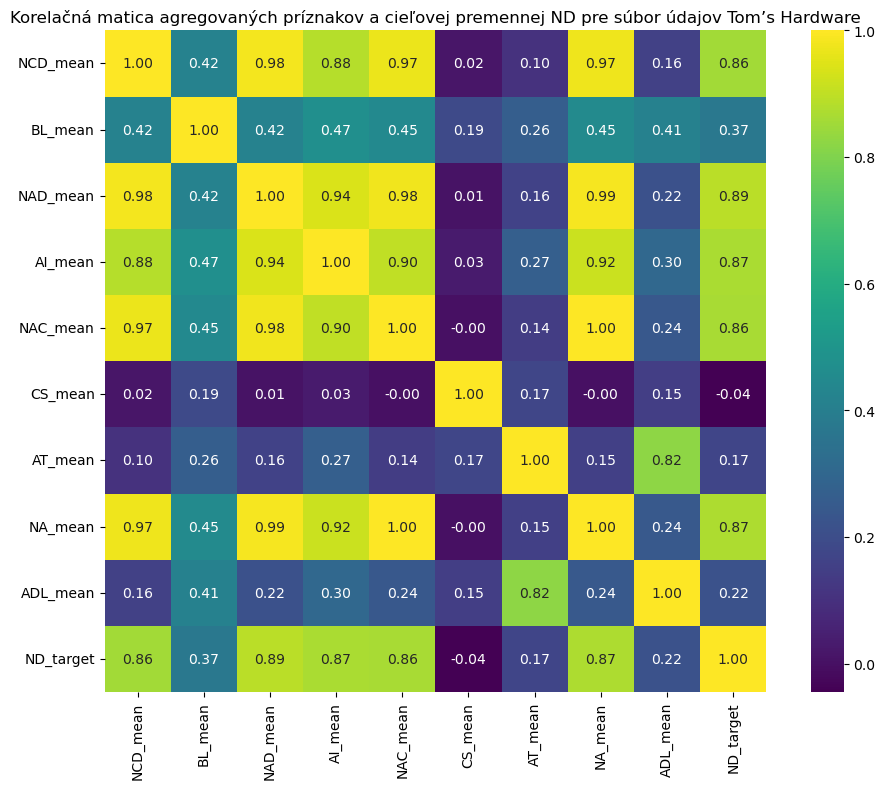

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

base_features = [
    "NCD", "BL", "NAD", "AI", "NAC",
    "CS", "AT", "NA", "ADL"
]

agg_features = {}

for feature in base_features:
    cols = [col for col in TH_reg.columns if col.startswith(feature)]
    agg_features[f"{feature}_mean"] = TH_reg[cols].mean(axis=1)

agg_df_TH = pd.DataFrame(agg_features)
agg_df_TH["ND_target"] = TH_reg["label"]

corr_TH = agg_df_TH.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_TH,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    square=True
)
plt.title("Korelačná matica agregovaných príznakov a cieľovej premennej ND pre súbor údajov Tom’s Hardware")
plt.tight_layout()
plt.show()


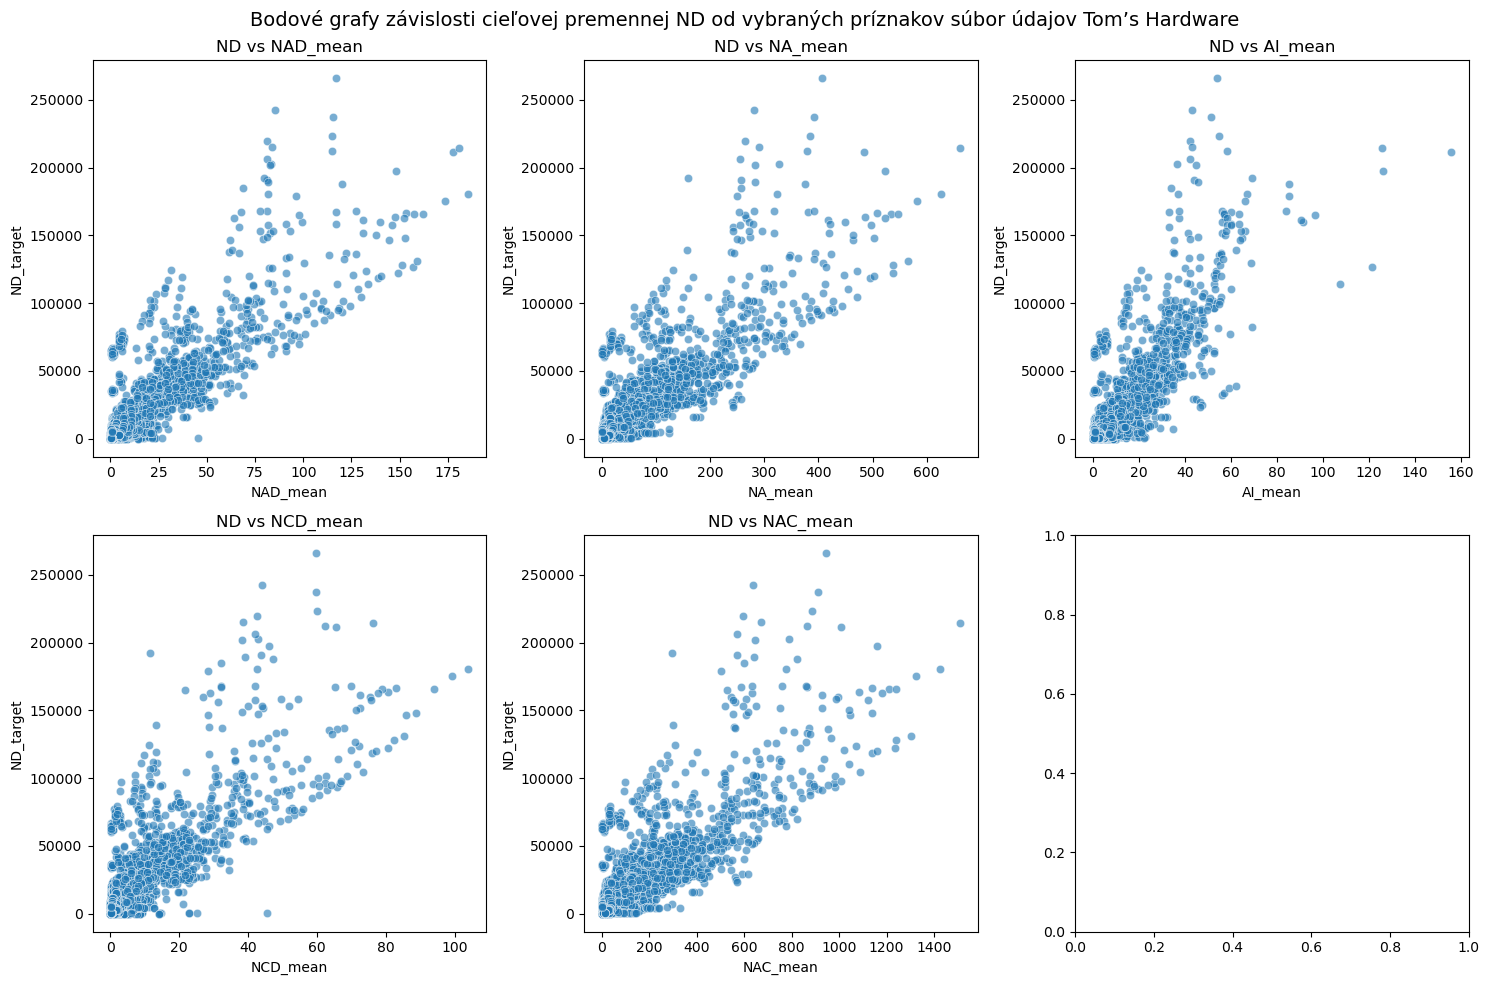

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ["NAD_mean", "NA_mean", "AI_mean", "NCD_mean", "NAC_mean"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.scatterplot(
        x=agg_df_TH[feature],
        y=agg_df_TH["ND_target"],
        alpha=0.6,
        ax=ax
    )
    ax.set_title(f"ND vs {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("ND_target")



plt.suptitle("Bodové grafy závislosti cieľovej premennej ND od vybraných príznakov súbor údajov Tom’s Hardware", fontsize=14)
plt.tight_layout()
plt.show()
